# Credit-Card Fraud Detection — EDA & Tabular Baseline Models

This notebook covers the **tabular (point-wise) formulation** of the problem: each
transaction is classified independently from its own attributes. It contains:

1. **Exploratory Data Analysis** (time, geography, behaviour, demographics)
2. **Baseline models** — K-Nearest Neighbours, Linear Discriminant Analysis, Random Forest

Gradient-boosting ensembles (CatBoost / XGBoost / LightGBM / Voting) live in a separate
notebook of the same *tabular* experiment. The **sequential (LSTM)** formulation is a
different experiment with a different protocol — its metrics are **not** directly comparable
to the tabular ones (see the LSTM notebook).

**Evaluation protocol here:** stratified k-fold CV, then a held-out test split.


## Data dictionary

| Column | Meaning | Use |
|---|---|---|
| `trans_date_trans_time` | transaction timestamp | source for time features |
| `cc_num` | card identifier | dropped (ID) |
| `merchant` | merchant name | EDA only, then dropped |
| `category` | merchant category | **categorical feature** |
| `amt` | transaction amount | numeric feature |
| `first`,`last`,`street`,`city`,`zip`,`job`,`trans_num` | PII / identifiers | dropped |
| `gender` | card-holder gender | **categorical feature** |
| `state` | card-holder state | **categorical feature** |
| `lat`,`long` | card-holder home coordinates | numeric (+ distance) |
| `city_pop` | city population | numeric feature |
| `dob` | date of birth | source for `card_holder_age`, then dropped |
| `unix_time` | unix timestamp | **excluded from features** (ordering only) |
| `merch_lat`,`merch_long` | merchant coordinates | numeric (+ distance) |
| `merch_zipcode` | merchant zip | dropped |
| `is_fraud` | **target** | label |


## Load data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

RANDOM_SEED = 42
sns.set_theme(style="whitegrid")

CSV_PATH = "/kaggle/input/datasets/priyamchoksi/credit-card-transactions-dataset/credit_card_transactions.csv"
df = pd.read_csv(CSV_PATH)
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
print(df.shape)

(1296675, 24)


## Feature engineering

- Time parts from the timestamp (cyclical, generalise across time).
- **Haversine** distance between home and merchant (vectorised; not Euclidean — one degree
  of longitude shrinks with latitude).
- Card-holder age.

`unix_time` and `trans_year` are kept for ordering/age but **excluded from model features**.

In [2]:
ts = df["trans_date_trans_time"].dt
df["trans_year"]    = ts.year        # for age only; not a model feature
df["trans_month"]   = ts.month
df["trans_day"]     = ts.day
df["trans_season"]  = ts.month % 12 // 3 + 1   # 1=Winter 2=Spring 3=Summer 4=Autumn
df["trans_weekday"] = ts.weekday
df["trans_hour"]    = ts.hour
df["trans_minute"]  = ts.minute
df["trans_second"]  = ts.second

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df["distance"] = haversine_km(df["lat"], df["long"], df["merch_lat"], df["merch_long"])

df["dob"] = pd.to_datetime(df["dob"])
df["card_holder_age"] = df["trans_year"] - df["dob"].dt.year

## Exploratory Data Analysis

### Target distribution
Severe class imbalance — fraud is a tiny fraction of all transactions. This is why we later
report **PR-AUC** and use **class weights**, and why raw accuracy is meaningless here.

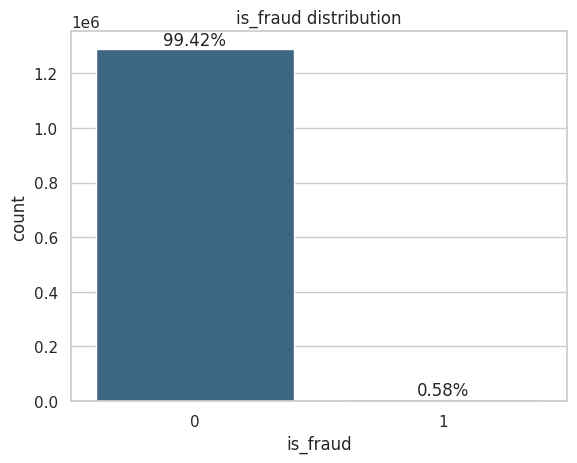

Fraud rate: 0.5789%


In [3]:
total = len(df)
ax = sns.countplot(x="is_fraud", data=df, palette="viridis", hue="is_fraud", legend=False)
for p in ax.patches:
    ax.annotate(f"{p.get_height()/total*100:.2f}%",
                (p.get_x()+p.get_width()/2, p.get_height()), ha="center", va="bottom")
plt.title("is_fraud distribution"); plt.show()
print(f"Fraud rate: {df['is_fraud'].mean():.4%}")

### Fraud rate over time (month, season, hour, weekday)

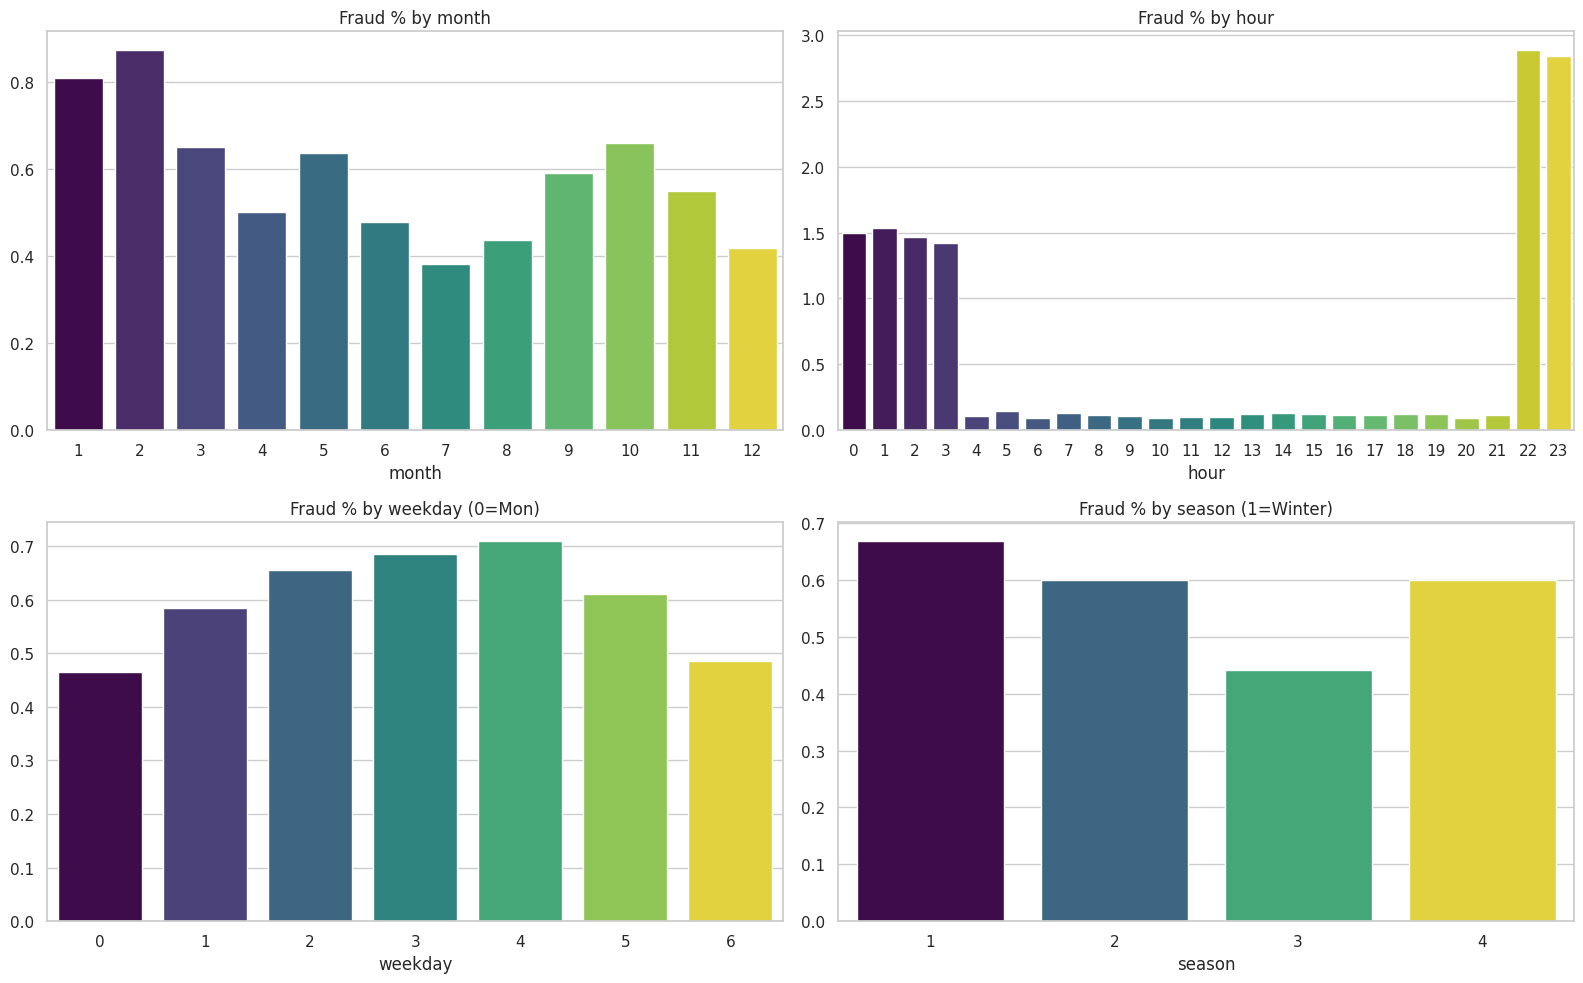

In [4]:
def fraud_rate_by(col, order=None):
    r = df.groupby(col)["is_fraud"].mean().mul(100)
    return r.reindex(order) if order is not None else r

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

m = fraud_rate_by("trans_month")
sns.barplot(x=m.index, y=m.values, ax=axes[0,0], palette="viridis", hue=m.index, legend=False)
axes[0,0].set_title("Fraud % by month"); axes[0,0].set_xlabel("month")

h = fraud_rate_by("trans_hour")
sns.barplot(x=h.index, y=h.values, ax=axes[0,1], palette="viridis", hue=h.index, legend=False)
axes[0,1].set_title("Fraud % by hour"); axes[0,1].set_xlabel("hour")

w = fraud_rate_by("trans_weekday")
sns.barplot(x=w.index, y=w.values, ax=axes[1,0], palette="viridis", hue=w.index, legend=False)
axes[1,0].set_title("Fraud % by weekday (0=Mon)"); axes[1,0].set_xlabel("weekday")

s = fraud_rate_by("trans_season")
sns.barplot(x=s.index, y=s.values, ax=axes[1,1], palette="viridis", hue=s.index, legend=False)
axes[1,1].set_title("Fraud % by season (1=Winter)"); axes[1,1].set_xlabel("season")

plt.tight_layout(); plt.show()

**Insight:** fraud rate is **time-dependent** — higher in winter months and
concentrated in specific hours. This motivates the sequential (LSTM) experiment and the
cyclical time features here.

### Geography — state & city population

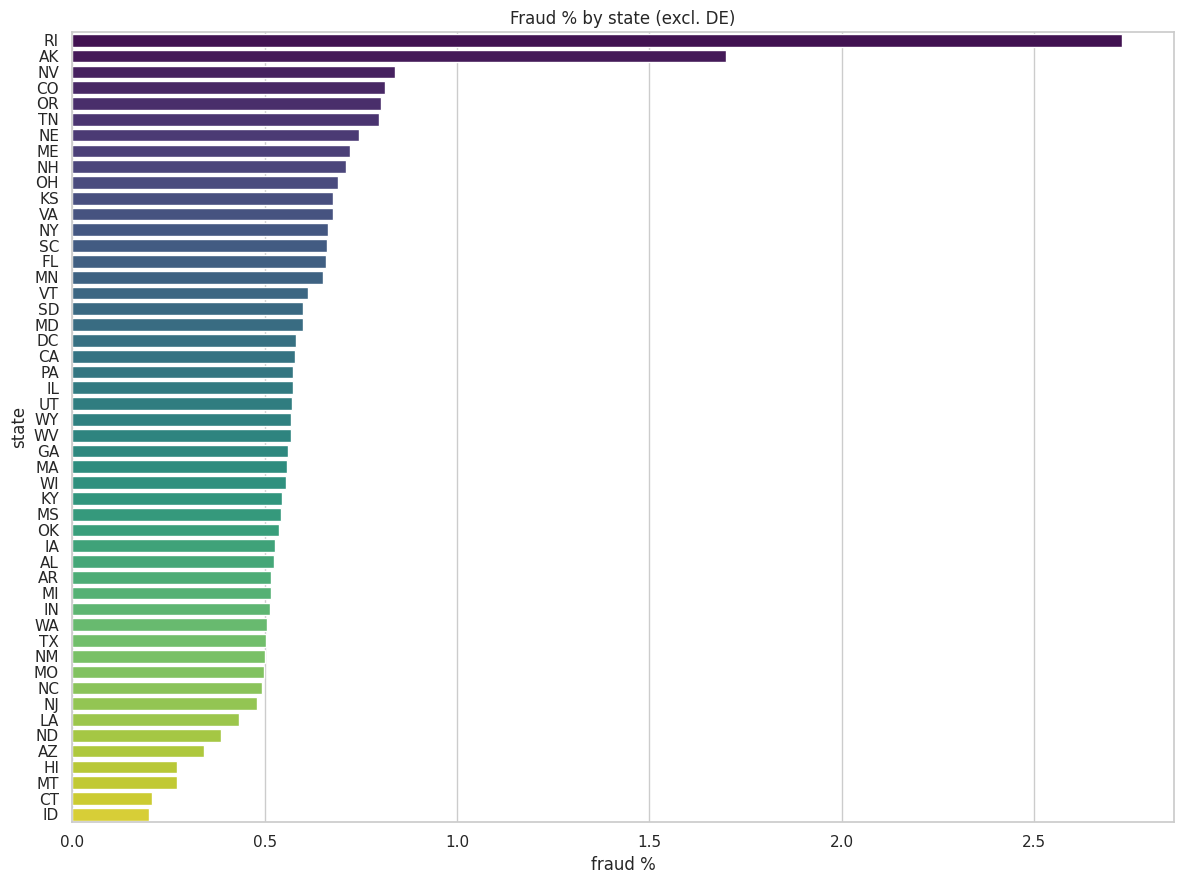

In [5]:
state_rate = (df[df["state"] != "DE"].groupby("state")["is_fraud"].mean()*100
              ).sort_values(ascending=False)

plt.figure(figsize=(12, 9))
sns.barplot(x=state_rate.values, y=state_rate.index, palette="viridis",
            hue=state_rate.index, legend=False)
plt.title("Fraud % by state (excl. DE)"); plt.xlabel("fraud %"); plt.tight_layout(); plt.show()

In [6]:
# choropleth (plotly)
sr = (df[df["state"] != "DE"].groupby("state")["is_fraud"].mean()*100).reset_index()
sr.columns = ["state", "fraud_pct"]
fig = px.choropleth(sr, locations="state", locationmode="USA-states", color="fraud_pct",
                    scope="usa", color_continuous_scale="Viridis",
                    title="Fraud % by state (excl. DE)")
fig.show()

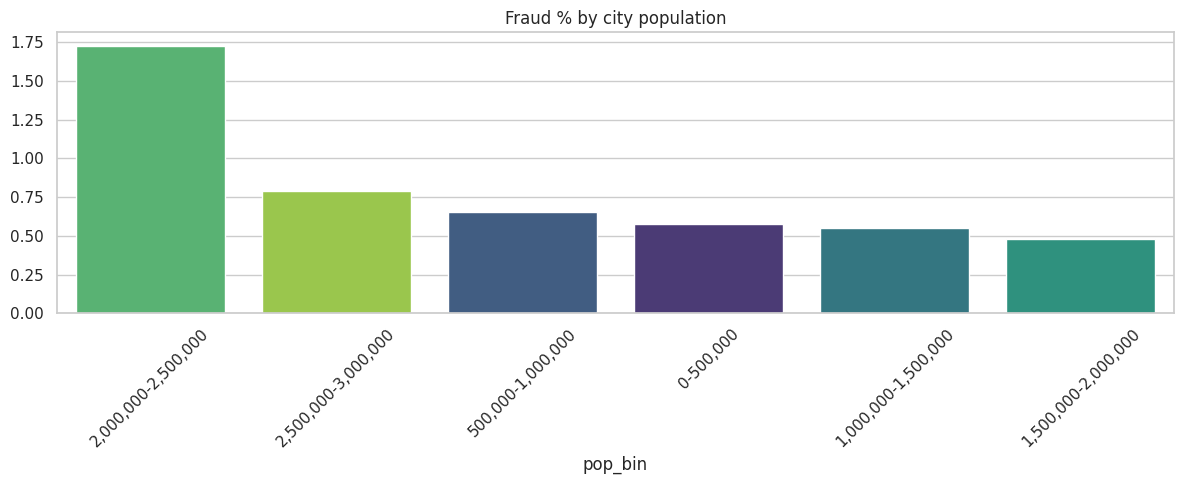

In [7]:
pop_bins = list(range(0, 3_000_001, 500_000))
pop_lab = [f"{pop_bins[i]:,}-{pop_bins[i+1]:,}" for i in range(len(pop_bins)-1)]
tmp = df.assign(pop_bin=pd.cut(df["city_pop"], bins=pop_bins, labels=pop_lab, right=False))
rate = (tmp[tmp.is_fraud==1]["pop_bin"].value_counts() /
        tmp["pop_bin"].value_counts() * 100).sort_values(ascending=False)
plt.figure(figsize=(12,5))
sns.barplot(x=rate.index.astype(str), y=rate.values, palette="viridis", hue=rate.index, legend=False)
plt.title("Fraud % by city population"); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

### Behaviour — amount, distance, category

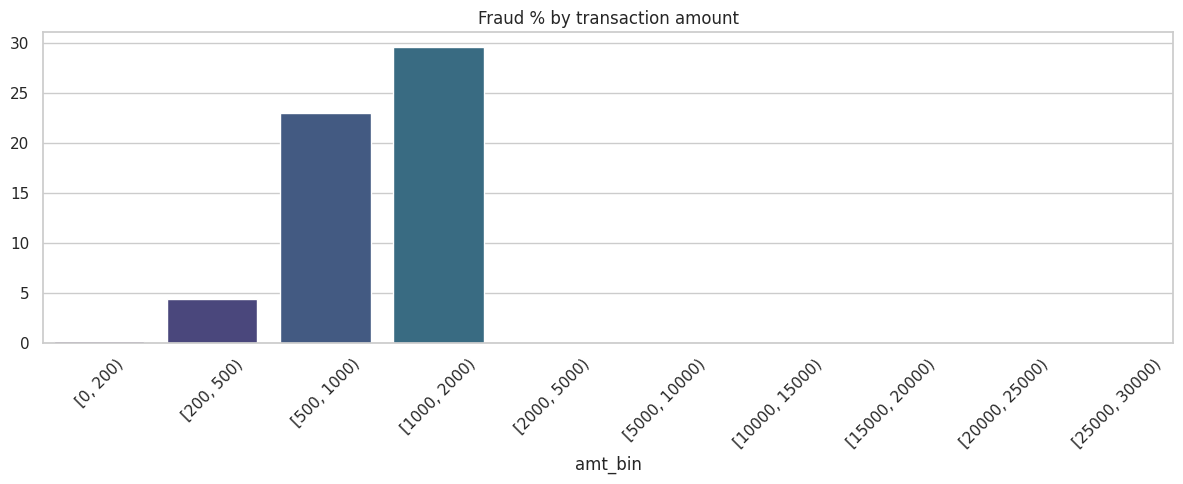

In [8]:
amt_bins = [0, 200, 500, 1000, 2000, 5000, 10000, 15000, 20000, 25000, 30000]
tmp = df.assign(amt_bin=pd.cut(df["amt"], bins=amt_bins, right=False))
rate = (tmp[tmp.is_fraud==1]["amt_bin"].value_counts() /
        tmp["amt_bin"].value_counts() * 100).sort_index()
plt.figure(figsize=(12,5))
sns.barplot(x=rate.index.astype(str), y=rate.values, palette="viridis", hue=rate.index, legend=False)
plt.title("Fraud % by transaction amount"); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

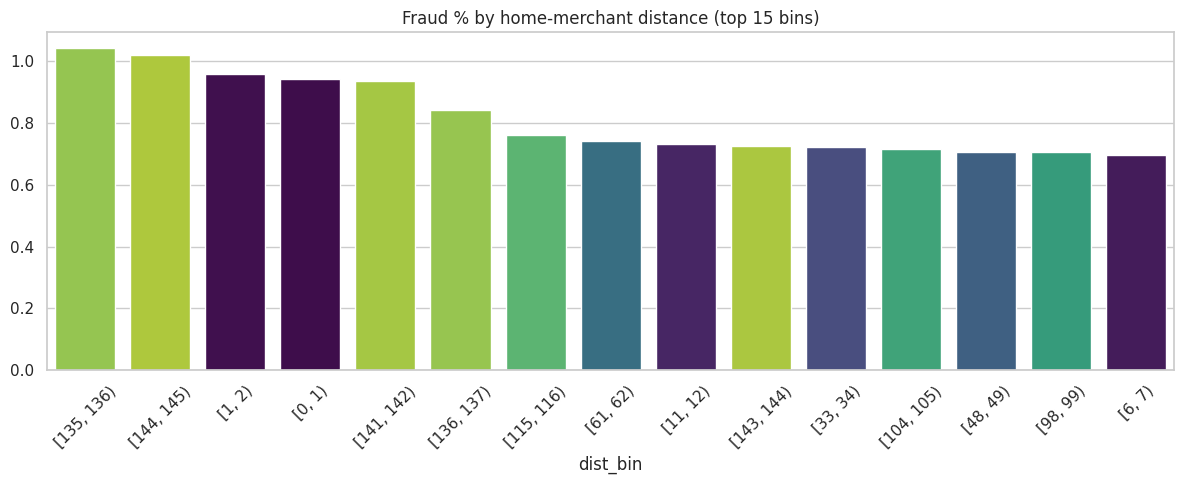

In [9]:
dist_bins = list(range(0, 161, 1))
tmp = df.assign(dist_bin=pd.cut(df["distance"], bins=dist_bins, right=False))
rate = (tmp[tmp.is_fraud==1]["dist_bin"].value_counts() /
        tmp["dist_bin"].value_counts() * 100).sort_values(ascending=False).head(15)
plt.figure(figsize=(12,5))
sns.barplot(x=rate.index.astype(str), y=rate.values, palette="viridis", hue=rate.index, legend=False)
plt.title("Fraud % by home-merchant distance (top 15 bins)"); plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

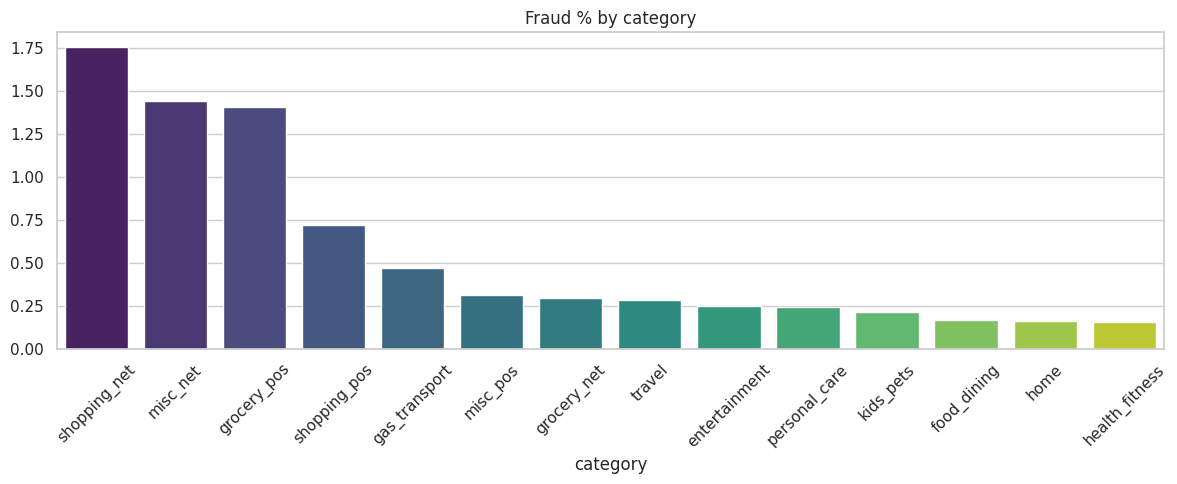

In [10]:
rate = (df.groupby("category")["is_fraud"].mean()*100).sort_values(ascending=False)
plt.figure(figsize=(12,5))
sns.barplot(x=rate.index, y=rate.values, palette="viridis", hue=rate.index, legend=False)
plt.title("Fraud % by category"); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

### Demographics — gender & age

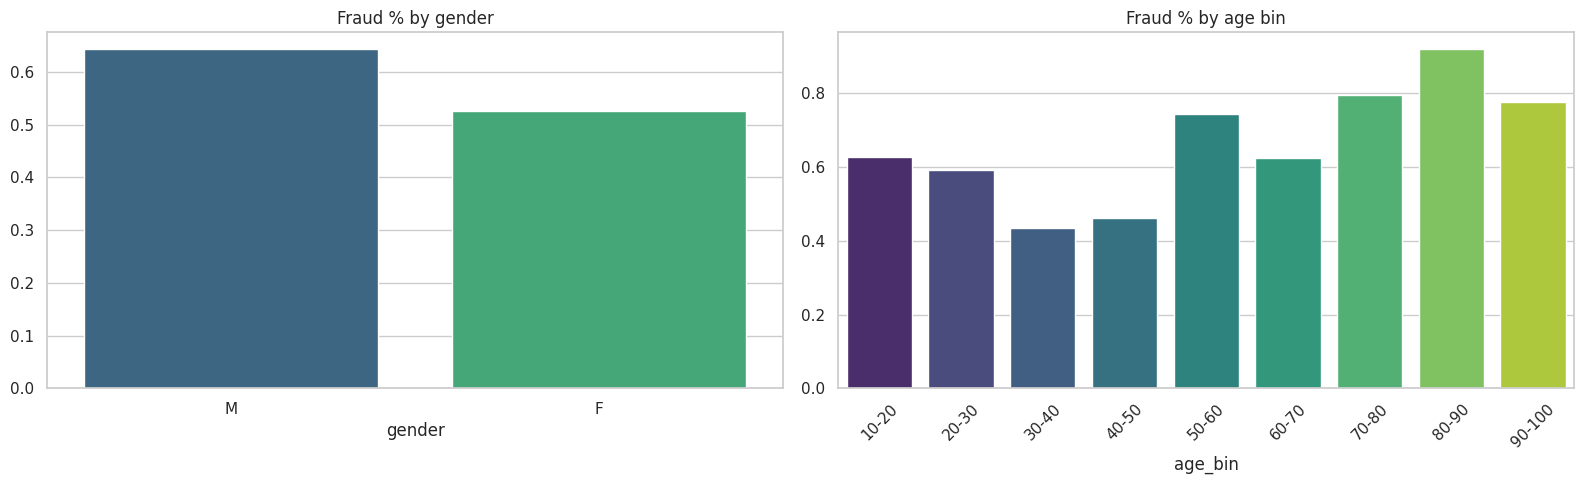

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
g = (df.groupby("gender")["is_fraud"].mean()*100).sort_values(ascending=False)
sns.barplot(x=g.index, y=g.values, ax=axes[0], palette="viridis", hue=g.index, legend=False)
axes[0].set_title("Fraud % by gender")

age_bins = list(range(10, 105, 10))
age_lab = [f"{age_bins[i]}-{age_bins[i+1]}" for i in range(len(age_bins)-1)]   # fixed labels
tmp = df.assign(age_bin=pd.cut(df["card_holder_age"], bins=age_bins, labels=age_lab, right=False))
rate = (tmp[tmp.is_fraud==1]["age_bin"].value_counts() /
        tmp["age_bin"].value_counts() * 100).sort_index()
sns.barplot(x=rate.index.astype(str), y=rate.values, ax=axes[1], palette="viridis",
            hue=rate.index, legend=False)
axes[1].set_title("Fraud % by age bin"); axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

### Data artifact — the `merchant` column
Every merchant name is prefixed with `fraud_` by the data simulator, for **all** rows
(fraud and non-fraud alike). This prefix is therefore **not** a signal and is stripped
before any merchant-level analysis; `merchant` is dropped from the model features anyway
(high-cardinality identifier).

In [12]:
print("merchant starts with 'fraud_':",
      df["merchant"].str.startswith("fraud", na=False).sum(), "of", len(df))
df["merchant"] = df["merchant"].str.split("_").str[1:].str.join("")  # strip the artifact prefix

merchant starts with 'fraud_': 1296675 of 1296675


## Baseline models (KNN · LDA · Random Forest)

### Features, split, preprocessing

- **One-hot** encoding (not label-encoding): KNN and LDA are distance/linear models, so
  integer category codes would impose a meaningless ordinal ranking and distort them.
  Preprocessing is wrapped in a `Pipeline` and **fit inside each CV fold**.
- Numerics are standard-scaled (matters for KNN/LDA; harmless for the tree).
- `unix_time`, `trans_year`, and all identifiers are excluded.

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             average_precision_score, precision_recall_curve,
                             classification_report)
from sklearn.model_selection import cross_val_predict

CATEGORICAL_FEATURES = ["category", "gender", "state"]
NUMERIC_FEATURES = [
    "amt", "lat", "long", "city_pop", "merch_lat", "merch_long",
    "trans_month", "trans_day", "trans_season", "trans_weekday",
    "trans_hour", "trans_minute", "trans_second", "distance", "card_holder_age",
]
X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df["is_fraud"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED)
print("train:", X_train.shape, "test:", X_test.shape)
print("fraud rate  train: %.4f  test: %.4f" % (y_train.mean(), y_test.mean()))

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_FEATURES),
])

cw = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)  # from TRAIN only
cw_dict = dict(zip(np.unique(y_train), cw))
print("class weights:", cw_dict)

train: (1037340, 18) test: (259335, 18)
fraud rate  train: 0.0058  test: 0.0058
class weights: {np.int64(0): np.float64(0.502911275191863), np.int64(1): np.float64(86.37302248126561)}


### Cross-validated PR-AUC via out-of-fold (OOF) predictions

We use `cross_val_predict` to get **out-of-fold** fraud-probabilities: every training row is
predicted exactly once, by the fold that did **not** train on it. Pooling these gives a clean,
leak-free probability for all of `X_train`, which we use for **two** things:
1. a threshold-independent **CV PR-AUC** (this table), and
2. **threshold tuning** in the next step — reusing the same OOF pass.

In [14]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "LDA": LinearDiscriminantAnalysis(),
    "RandomForest": RandomForestClassifier(
        n_estimators=300, random_state=6, class_weight=cw_dict, n_jobs=-1),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

oof = {}   # OOF fraud-probabilities per model (reused for the table AND threshold tuning)
rows = []
for name, clf in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", clf)])
    oof_proba = cross_val_predict(pipe, X_train, y_train, cv=skf,
                              method="predict_proba", n_jobs=1)[:, 1]
    oof[name] = oof_proba
    rows.append({"Model": name, "CV PR-AUC": average_precision_score(y_train, oof_proba)})
    print(f"{name}: OOF predictions computed")

cv_results = pd.DataFrame(rows).set_index("Model").round(4)
cv_results   

KNN: OOF predictions computed
LDA: OOF predictions computed
RandomForest: OOF predictions computed


,CV PR-AUC
Model,
KNN,0.4821
LDA,0.2021
RandomForest,0.9125


### Threshold tuning (on OOF) + Test evaluation

The decision threshold is chosen on the **OOF predictions of train only** — the test set is
never touched during tuning. Each model is then refit on the full training set and evaluated
on the held-out test set with its **frozen** threshold. PR-AUC is threshold-independent;
Precision/Recall/F1 are at the tuned threshold.

### Final evaluation on the held-out test set

In [15]:
def tune_threshold(y_true, y_prob):
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    f1 = np.where((prec + rec) > 0, 2 * prec * rec / (prec + rec), 0.0)
    return float(thr[np.argmax(f1[:-1])]) if len(thr) else 0.5


from joblib import dump
rows = []
for name, clf in models.items():
    thr = tune_threshold(y_train, oof[name])        # tuned on OOF of TRAIN only
    pipe = Pipeline([("prep", preprocessor), ("model", clf)])
    pipe.fit(X_train, y_train)                       # refit on full train
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= thr).astype(int)                # apply frozen threshold to test
    rows.append({"Model": name, "Threshold": round(thr, 3),
                 "PR-AUC": average_precision_score(y_test, proba),
                 "Precision": precision_score(y_test, pred, zero_division=0),
                 "Recall": recall_score(y_test, pred, zero_division=0),
                 "F1": f1_score(y_test, pred, zero_division=0)})
    dump(pipe, f"/kaggle/working/{name}.joblib")
    print(f"{name}: threshold={thr:.3f} (tuned on OOF), model saved")

test_results = pd.DataFrame(rows).set_index("Model").round(4)
test_results

KNN: threshold=0.400 (tuned on OOF), model saved
LDA: threshold=0.986 (tuned on OOF), model saved
RandomForest: threshold=0.277 (tuned on OOF), model saved


,Threshold,PR-AUC,Precision,Recall,F1
Model,,,,,
KNN,0.400,0.4986,0.7089,0.5030,0.5885
LDA,0.986,0.2065,0.3988,0.4124,0.4055
RandomForest,0.277,0.9262,0.9377,0.8121,0.8704


## Notes

- **PR-AUC is the fair comparison metric** here (threshold-independent, imbalance-aware).
- **The decision threshold is tuned on out-of-fold predictions of the training set**, then
  frozen and applied to the test set — so Precision/Recall/F1 reflect a sensible operating
  point rather than the arbitrary 0.5 default, and the test set stays untouched during tuning.
  Precision/Recall/F1 are reported at the default 0.5 threshold.
- **Random Forest is the strongest baseline;** KNN and LDA trail because linear/distance
  assumptions fit this data poorly even after one-hot encoding. Gradient-boosting ensembles
  (separate notebook) push PR-AUC substantially higher and are the recommended backbone for
  this tabular formulation.
- **KNN is the slow model** (lazy, distance over ~80 one-hot dims on ~1M rows); subsample if
  iterating quickly.